In [1]:
import os
import numpy as np
import pandas as pd

import geopandas as gpd

import cmocean.cm as cmo

import xarray as xr
import rasterio
import rasterio.plot as rplt
from affine import Affine

from shapely.geometry import LineString, Point


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from PyPDF2 import PdfReader, PdfWriter
import app


In [2]:
base_directory = r"D:\PhD\21_Experiments\TidesDamageDriver"
drainages_folder = os.path.join(
    base_directory, "03_cleaned", "drainages"
)
lake_extent_path = os.path.join(
    base_directory, "03_cleaned", "lake_extents", "lakes_extent.shp"
)
lima_folder = os.path.join(
    base_directory, "01_raw", "LIMA"
)


coastline_folder = os.path.join(
    base_directory, "01_raw", "greene2022_coastlines"
)
iceshelf_folder = os.path.join(
    base_directory, "01_raw", "greene2022_iceshelves"
)
add_path = os.path.join(
    base_directory, "01_raw", "high_res_coastline", "add_coastline_high_res_line_v7_6.shp"
)
lai_path = os.path.join(
    base_directory, "01_raw", "lai2020_vulnerability", "vulnerable.nc"
)
fuerst_path = os.path.join(
    base_directory, "01_raw", "fuerst2016_psi", "psi.nc"
)

grid_path = os.path.join(
    base_directory, "01_raw", "grid", "ne_110m_graticules_1.shp"
)
tides_folder = os.path.join(
    base_directory, "01_raw", "tides_CATS2008"
)
data_dmg_folder = os.path.join(
    base_directory, "03_cleaned", "dmg_resampled"
)
figure_folder = os.path.join(
    base_directory, "figures"
)

In [3]:
events = app.lakes.plotting.get_geodataframes(drainages_folder)[0]
events.to_crs(
    "EPSG:3031", inplace=True
)
drainage_color = "#3943d8"

In [4]:
lake_extent = gpd.read_file(lake_extent_path).buffer(50)
lake_color = "deepskyblue"

In [5]:
years = [2016, 2018, 2019, 2020]
total_width = 18 / 2.54
xmin = 2.50e6
xmax = 2.77e6
ymax = -0.215e6
ymin = -0.591e6
ymax_z, ymin_z = -0.34e6, -0.50e6
deltay_zoomed = abs(ymax_z - ymin_z)
deltax_zoomed = 0.66 * deltay_zoomed
xmin_z = 2.54e6
xmax_z = xmin_z + deltax_zoomed

vertical_line = LineString([(xmin, ymin), (xmin, ymax)])

In [6]:
all_coastline_files = os.listdir(coastline_folder)
coastlines = [
    gpd.read_file(os.path.join(coastline_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_coastline_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
buffer = 6e3
coastlines_buffer = [c.buffer(buffer) for c in coastlines]

In [7]:
all_iceshelves_files = os.listdir(iceshelf_folder)
iceshelves = [
    gpd.read_file(os.path.join(iceshelf_folder, f)).cx[xmin:xmax, ymin:ymax]
    for f in all_iceshelves_files
    if f.endswith(".shp") and any([str(s) in f for s in years])
]
ice_buffer = 150
for ice in iceshelves:
    ice.geometry = ice.buffer(ice_buffer)
    ice = ice.dissolve()
    ice.geometry = ice.buffer(-ice_buffer)
cmap = mpl.colormaps["cmo.ice"]
ice_colors = cmap(np.linspace(0.2, 0.8, 3))

buffer = 6e3
iceshelves_buffer = [i.buffer(buffer) for i in iceshelves]

In [8]:
add = gpd.read_file(
    add_path
)
add.columns
add["surface"].unique()

shelf_lines = add[add["surface"].isin(["ice shelf and front"])]
grounding_lines = add[
    add["surface"].isin(
        [
            "ice coastline",
            "grounding line",
            "ice rumples",
            "rock against ice shelf",
            "rock coastline",
        ]
    )
]

shelf = shelf_lines.cx[xmin:xmax, ymin:ymax]
grounding_line = grounding_lines.cx[xmin:xmax, ymin:ymax]

In [9]:
grid = gpd.read_file(grid_path)  # https://www.naturalearthdata.com/about/terms-of-use/
grid.to_crs("EPSG:3031", inplace=True)
grid = grid.cx[xmin:xmax, ymin:ymax]

grid_filtered = gpd.GeoDataFrame(grid[grid["degrees"].isin([65, 66, 100, 95])].cx[xmin: xmax, ymin: ymax])
grid_filtered_S = grid_filtered.query("direction == 'S'")
grid_filtered_E = grid_filtered.query("direction == 'E'")

label_points_grid = []

for idx, row in grid_filtered.iterrows():
    line = row.geometry
    intersection = line.intersection(vertical_line)

    if not intersection.is_empty:
        if intersection.geom_type == "Point":
            x_int, y_int = intersection.x, intersection.y
            if ymin <= y_int <= ymax:
                label_points_grid.append({
                    "label": row["display"],
                    "x": x_int,
                    "y": y_int
                })
        elif intersection.geom_type in ["MultiPoint", "GeometryCollection"]:
            for geom in intersection.geoms:
                if geom.geom_type == "Point":
                    x_int, y_int = geom.x, geom.y
                    if ymin <= y_int <= ymax:
                        label_points_grid.append({
                            "label": row["display"],
                            "x": x_int,
                            "y": y_int
                        })
grid.head()

,degrees,direction,display,scalerank,dd,geometry
154,65,S,65 S,6,-65,"LINESTRING (-2.112e-9 -2758494.765, 161.696 -2..."
155,66,S,66 S,6,-66,"LINESTRING (2.365 -2644909.451, 155.038 -26449..."
156,67,S,67 S,6,-67,"LINESTRING (2.264 -2531747.008, 148.404 -25317..."
256,103,E,103 E,6,103,"LINESTRING (7.141 -1.648, 52938.639 -12219.281..."
257,102,E,102 E,6,102,"LINESTRING (7.169 -1.523, 53143.83 -11293.522,..."


In [25]:
dmgs = []
dmgs_transforms = []
dmgs_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_dmg.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        masked = masked
        masked = (masked / np.nanmax(masked)).copy()

    dmgs.append(masked)
    dmgs_transforms.append(masked_transform)
    dmgs_meta.append(meta)

dmg_results = []
for dmg in dmgs:
    res = app.dmg.categorize(dmg, number_bins=10, medium=7, high=9)
    dmg_results.append(res)

dmg_limit_medium = float(np.array([res["medium"]["limits"][0] for res in dmg_results]).mean())
dmg_limit_high = float(np.array([res["high"]["limits"][0] for res in dmg_results]).mean())
dmg_fractions = (float(dmg_results[0]["low"]["fraction"]), float(dmg_results[0]["medium"]["fraction"]), float(dmg_results[0]["high"]["fraction"]))


In [11]:
acts = []
acts_transforms = []
acts_meta = []
for i_year, year in enumerate(years):
    path = os.path.join(
        data_dmg_folder, f'{year}', f'S1_{year}1101_{year}1110_3000m_act.tif'
    )
    with rasterio.open(path) as src:
        raster = src.read(1)
        meta = src.meta.copy()
        transform = src.transform

        raster[raster == 0] = np.nan
        masked, masked_transform = app.dmg.tiffiles.mask_dataset(
            raster, transform, iceshelves_buffer[i_year], mode="shape", filled=False
        )
        masked = masked
        masked = (masked / np.nanmax(masked)).copy()
    acts.append(masked)
    acts_transforms.append(masked_transform)
    acts_meta.append(meta)

act_results = []
for act in acts:
    res = app.dmg.categorize(act, number_bins=10, medium=2, high=8)
    act_results.append(res)

act_limit_medium = float(np.array([res["medium"]["limits"][0] for res in act_results]).mean())
act_limit_high = float(np.array([res["high"]["limits"][0] for res in act_results]).mean())
act_fractions = (float(act_results[0]["low"]["fraction"]), float(act_results[0]["medium"]["fraction"]), float(act_results[0]["high"]["fraction"]))

In [12]:
fuerst = xr.open_dataset(fuerst_path, engine="netcdf4")
da = fuerst["PSI"]
da = da.rio.write_crs("EPSG:3031", inplace=True)
fuerst_raster = da.values  # 2D NumPy array
fuerst_transform = da.rio.transform()  # Affine transform from xarray
fuerst_raster_1 = fuerst_raster.copy()
fuerst_raster_1[fuerst_raster != 1] = np.nan

fuerst_color = "#fa5f7e"
cmap_fuerst_color = ListedColormap([fuerst_color])

In [13]:
lai = xr.open_dataset(lai_path, engine="netcdf4")
da = lai["vulnerable"]
da = da.rio.write_crs("EPSG:3031", inplace=True)
lai_raster = da.values  # 2D NumPy array
lai_transform = da.rio.transform()  # Affine transform from xarray
lai_raster_0 = lai_raster.copy()
lai_raster_0[lai_raster != 0] = np.nan
lai_raster_1 = lai_raster.copy()
lai_raster_1[lai_raster != 1] = np.nan

lai_vulnerable_color = "#a31430"
lai_no_color = "#150016"
lai_nan_color = "#675E68"
cmap_lai_vulnerable_color = ListedColormap([lai_vulnerable_color])
cmap_lai_no_color = ListedColormap([lai_no_color])
cmap_lai_nan_color = ListedColormap([lai_nan_color])

events["lai"].fillna(-1, inplace=True)

C:\Users\jsommer1\AppData\Local\Temp\ipykernel_26648\2977829270.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  events["lai"].fillna(-1, inplace=True)


In [14]:
year_show = 2019
i_year_show = years.index(year_show)

In [15]:
gird_label_font = 5
cmap_gray = app.lakes.plotting.truncate_colormap(plt.get_cmap("cmo.gray_r"), 0.0, 0.8)
CMAP_DMG = app.lakes.plotting.truncate_colormap(plt.get_cmap("cmo.amp"), 0.0, 1)
CMAP_ACT = app.lakes.plotting.truncate_colormap(plt.get_cmap("cmo.rain"), 0.0, 1)
DICT_LAI = {
    -1: lai_nan_color,
    0: lai_no_color,
    1: lai_vulnerable_color,
    2: fuerst_color
}
ss = [20, 12]
ssp = [10, 6]

In [16]:
step_y = 3e3
step_x = 3e3
events["x_offset"] = 0
events["y_offset"] = 0

# A
events["y_offset"].values[0] = 3 * step_y
events["x_offset"].values[0] = -5 * step_x
# B
events["y_offset"].values[1] = 0 * step_y
events["x_offset"].values[1] = -5 * step_x
# C
events["y_offset"].values[2] = -3 * step_y
events["x_offset"].values[2] = -5 * step_x
# D
events["y_offset"].values[3] = -2 * step_y
events["x_offset"].values[3] = -5 * step_x
# E
events["y_offset"].values[4] = 0 * step_y
events["x_offset"].values[4] = -5 * step_x
# F
events["y_offset"].values[5] = 0 * step_y
events["x_offset"].values[5] = -5 * step_x
# G
events["y_offset"].values[6] = 3 * step_y
events["x_offset"].values[6] = -5 * step_x
# H
events["y_offset"].values[7] = 3 * step_y
events["x_offset"].values[7] = 4 * step_x
# I
events["y_offset"].values[8] = -3 * step_y
events["x_offset"].values[8] = 4 * step_x
# J
events["y_offset"].values[9] = 1 * step_y
events["x_offset"].values[9] = 5 * step_x
# K
events["y_offset"].values[10] = 3 * step_y
events["x_offset"].values[10] = -5 * step_x
# L
events["y_offset"].values[11] = 1 * step_y
events["x_offset"].values[11] = -5 * step_x
# M
events["y_offset"].values[12] = -2.5 * step_y
events["x_offset"].values[12] = -5 * step_x
# N
events["y_offset"].values[13] = 4 * step_y
events["x_offset"].values[13] = 0.5 * step_x
# O
events["y_offset"].values[14] = 4 * step_y
events["x_offset"].values[14] = 2.5 * step_x
# P
events["y_offset"].values[15] = -4 * step_y
events["x_offset"].values[15] = -2 * step_x
# Q
events["y_offset"].values[16] = -7 * step_y
events["x_offset"].values[16] = -2 * step_x
# R
events["y_offset"].values[17] = -4.5 * step_y
events["x_offset"].values[17] = -3 * step_x
# S
events["y_offset"].values[18] = 2 * step_y
events["x_offset"].values[18] = 4 * step_x
# T
events["y_offset"].values[19] = -3.5 * step_y
events["x_offset"].values[19] = -4.5 * step_x
# U
events["y_offset"].values[20] = -6.5 * step_y
events["x_offset"].values[20] = -4.5 * step_x
# V
events["y_offset"].values[21] = -4 * step_y
events["x_offset"].values[21] = -1 * step_x
# W
events["y_offset"].values[22] = 0 * step_y
events["x_offset"].values[22] = 4 * step_x
# X
events["y_offset"].values[23] = 1 * step_y
events["x_offset"].values[23] = 4 * step_x
# Y
events["y_offset"].values[24] = -4 * step_y
events["x_offset"].values[24] = 2 * step_x
events_zoomed = events.cx[xmin_z:xmax_z, ymin_z:ymax_z]

In [17]:
events_centroids = events.geometry.centroid

xs = events_centroids.x.values
ys = events_centroids.y.values
xs_label = xs + events["x_offset"].values
ys_label = ys + events["y_offset"].values
event_labels = events["label"]

C:\Users\jsommer1\AppData\Local\Temp\ipykernel_26648\3475505258.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 1 Axes> than <Figure size 196.85x708.661 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(


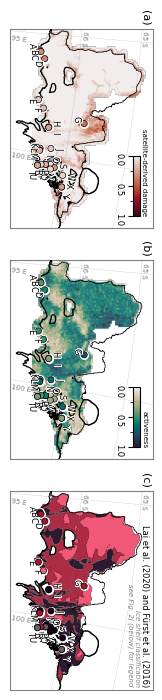

In [34]:
fig, axes = plt.subplots(3, 1,
                        figsize=(5 / 2.54, total_width),
                        height_ratios=[1, 1, 1])


for i, (data, ax, cmap, name) in enumerate(zip(
    [dmgs[i_year_show], acts[i_year_show]],
    axes.ravel()[:2],
    [CMAP_DMG, CMAP_ACT],
    ["satellite-derived damage", "activeness"])
    ):
    fig_silent, ax_silent = plt.subplots()
    data_silent = ax_silent.imshow(data[0] / np.nanmax(data[0]), cmap=cmap)
    plt.close()
    ax.text(0.94, 0.06, name, transform=ax.transAxes, va ="bottom", ha="center", rotation=-90, fontsize=5)
    cax = ax.inset_axes([0.86, 0.06, 0.05, 0.3], transform=ax.transAxes)
    cbar = fig.colorbar(
        data_silent, cax=cax, orientation="vertical", ticklocation="left"
    )

    # Make ticks and labels gray
    cbar.ax.tick_params(
        axis='y',
        rotation=-90,
        labelsize=6,
    )
    cbar.ax.set_ylim(0, 1)
    cbar.ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    cbar.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    cbar.ax.invert_yaxis()

ax = axes.ravel()[0]
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
rplt.show(dmgs[i_year_show], transform= dmgs_transforms[i_year_show], ax=ax, cmap=CMAP_DMG, alpha=0.9, zorder = 1)

ax = axes.ravel()[1]
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
rplt.show(acts[i_year_show], transform= acts_transforms[i_year_show], ax=ax, cmap=CMAP_ACT, alpha=0.9, zorder = 1)

ax = axes.ravel()[2]

rplt.show(lai_raster_0, ax=ax, transform=lai_transform, alpha=0.9, cmap=cmap_lai_no_color, zorder = 1)
rplt.show(lai_raster_1, ax=ax, transform=lai_transform, alpha=0.9, cmap=cmap_lai_vulnerable_color, zorder = 1)
rplt.show(fuerst_raster_1, ax=ax, transform=fuerst_transform, alpha=0.9, cmap=cmap_fuerst_color, zorder = 1)

for i, ax in enumerate(axes.ravel()):
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    grid_filtered.plot(ax=ax, color="gray", linewidth=0.2, ls="--", alpha = 0.8, zorder = 15)
    #events.plot(ax = ax, color="black", markersize=10, zorder=20, facecolor = events)
    coastlines[i_year_show].plot(ax=ax, facecolor="none", edgecolor="black", lw=0.5, zorder = 3)
    grounding_line.plot(ax=ax, facecolor="none", edgecolor="black", lw=0.9, zorder = 3)

    ax.tick_params(
        axis="both",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        bottom=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )
    # S labels (assume all same Y)
    ys_grid = np.full(len(grid_filtered_S), ymax - 3e3)
    xs_grid = grid_filtered_S.bounds.maxx - 5e3
    labels_grid = grid_filtered_S['degrees'].astype(str) + ' S'

    for x, y, s in zip(xs_grid, ys_grid, labels_grid):
        ax.text(x, y, s, rotation=-96, ha="center", va="top",
                fontsize=gird_label_font, color="gray", zorder=16)

    # E labels (assume all same Y)
    label_lookup = {l['label']: l['y'] for l in label_points_grid}
    xs_grid = np.full(len(grid_filtered_E), xmin + 2e3)
    ys_grid = grid_filtered_E['display'].map(label_lookup) - 1.5e4
    labels_grid = grid_filtered_E['degrees'].astype(str) + ' E'

    for x, y, s in zip(xs_grid, ys_grid, labels_grid):
        ax.text(x, y, s, rotation=-9, ha="left", va="center",
                fontsize=gird_label_font, color="gray", zorder=16)

    ax.spines["bottom"].set_color("gray")
    ax.spines["top"].set_color("gray")
    ax.spines["left"].set_color("gray")
    ax.spines["right"].set_color("gray")

    
    shadow_offset = 1e3
    half_offset = shadow_offset / 2
    for x, y, s in zip(xs_label, ys_label, event_labels):
        for dx, dy in [
            (-shadow_offset, 0), (-half_offset, 0), (half_offset, 0), (shadow_offset, 0),
            (0, -shadow_offset), (0, shadow_offset),
            (-shadow_offset, -shadow_offset), (-shadow_offset, shadow_offset),
            (shadow_offset, -shadow_offset), (shadow_offset, shadow_offset)
        ]:
            ax.text(
                x + dx, y + dy, s,
                rotation=-90,
                ha="center", va="center",
                fontsize=6,
                color="white",
                zorder=19  # Just below main text
                
            )

        ax.text(
            x, y, s,
            rotation=-90,
            ha="center", va="center",
            fontsize=6,
            color="black",
            zorder=20
        )



for i, (ax, cmap, value) in enumerate(zip(axes.ravel()[:2], [CMAP_DMG, CMAP_ACT], ['dmg', 'act'])):
    ax.scatter(
        events_centroids.x,
        events_centroids.y,
        s=ss[0] + ssp[0],
        color="white",
        zorder=17,
    )
    ax.scatter(
        events_centroids.x,
        events_centroids.y,
        s=ss[0],
        c=events[value].apply(cmap),
        edgecolors="black",
        linewidth=0.5,
        zorder=18,
    )

ax = axes.ravel()[2]
ax.scatter(
    events_centroids.x,
    events_centroids.y,
    s=ss[0] + ssp[0],
    color="white",
    zorder=19,
)
ax.scatter(
    events_centroids.x,
    events_centroids.y,
    s=ss[0],
    c=events["fuerst+lai"].fillna(-1, inplace=False).apply(DICT_LAI.get),
    edgecolors="black",
    linewidth=0.5,
    zorder=20,
)

captions = ["(a)", "(b)", "(c)"]
for i, ax in enumerate(axes.ravel()):
    ax.text(
        0.95, 1.06, captions[i],
        transform=ax.transAxes,
        fontsize=8,
        ha='center',
        va='center',
        color='black',
        zorder=21,
        rotation=-90,
    )




ax = axes.ravel()[2]
x0, y0 = 0.94, 0.02  # adjust for placement in axes coords
dx = 0.05


ax.text(x0, y0, "Lai et al. (2020) and Fürst et al. (2016)", fontsize = 6,
        transform=ax.transAxes, rotation=-90, va="bottom", ha="center", zorder=22, color = "black")
ax.text(x0 - dx, y0, "Ice shelf classification", fontsize = 5,
        transform=ax.transAxes, rotation=-90, va="bottom", ha="center", zorder=22, color = "gray", fontstyle="italic")
ax.text(x0 - 2 * dx, y0, "see Fig. 2j (below) for legend", fontsize = 5,
        transform=ax.transAxes, rotation=-90, va="bottom", ha="center", zorder=22, color = "gray", fontstyle="italic")
# # First patch + label
# ax.add_patch(plt.Rectangle((x0, y0), 0.02, 0.02, transform=ax.transAxes,
#                            color=lai_no_color, clip_on=False))
# ax.text(x0 - 0.01, y0 + 0.01, "no hydrofracture",
#         transform=ax.transAxes, rotation=-90, va="top", ha="left", fontsize=6)

# # Second patch + label
# ax.add_patch(plt.Rectangle((x0 + dx, y0), 0.02, 0.02, transform=ax.transAxes,
#                            color=lai_vulnerable_color, clip_on=False))
# ax.text(x0 - 0.01, y0 + dy + 0.01, "vulnerable",
#         transform=ax.transAxes, rotation=-90, va="top", ha="left", fontsize=6)

plt.tight_layout()
fig.savefig(
    os.path.join(figure_folder, "figure_02a.png"),
    dpi=300
)
fig.savefig(
    os.path.join(figure_folder, "figure_02a.pdf"),
    dpi=300
)
reader = PdfReader(os.path.join(figure_folder, "figure_02a.pdf"))
writer = PdfWriter()

for page in reader.pages:
    page.rotate(-90)  # or -90, 180
    writer.add_page(page)

with open(os.path.join(figure_folder, "figure_02a_r.pdf"), "wb") as f:
    writer.write(f)
    
plt.show()

In [20]:
events_lai_nan = events.query("lai == -1")
events_lai_no = events.query("lai+fuerst == 0")
events_lai_vul = events.query("lai+fuerst == 1")
events_passive = events.query("lai+fuerst == 2")

In [21]:
events_zoomed = events.cx[xmin_z:xmax_z, ymin_z:ymax_z]
events_zoomed_centroids = events_zoomed.geometry.centroid
xs_zoomed = events_zoomed_centroids.x.values
ys_zoomed = events_zoomed_centroids.y.values
xs_label_zoomed = xs_zoomed + 0.6 * events_zoomed["x_offset"].values
ys_label_zoomed = ys_zoomed + 0.6 * events_zoomed["y_offset"].values
event_labels_zoomed = events_zoomed["label"]

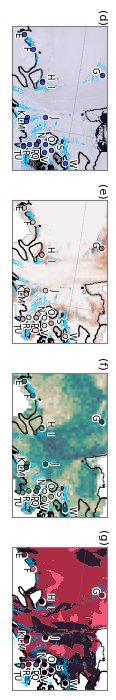

In [22]:
fig, axes = plt.subplots(4, 1,
                        figsize=(4.5 / 2.54, total_width),
                        height_ratios=[1, 1, 1, 1], sharex=True, sharey=True)

for iax, (ax, raster, cmap, v) in enumerate(zip(
        axes.ravel(),
        [None, dmgs[i_year_show], acts[i_year_show], None],
        [None, CMAP_DMG, CMAP_ACT, None],
        [None, "dmg", "act", "fuerst+lai"]
)):
    ax.set_xlim(xmin_z, xmax_z)
    ax.set_ylim(ymin_z, ymax_z)
    ax.spines["bottom"].set_color("gray")
    ax.spines["top"].set_color("gray")
    ax.spines["left"].set_color("gray")
    ax.spines["right"].set_color("gray")
    ax.tick_params(
        axis="both",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        bottom=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )

    grid_filtered.plot(ax=ax, color="gray", linewidth=0.2, ls="--", zorder = 15)
    coastlines[i_year_show].plot(ax=ax, facecolor="none", edgecolor="black", lw=0.5, alpha=1, zorder = 3)
    grounding_line.plot(ax=ax, facecolor="none", edgecolor="black", lw=0.9, zorder = 3)
    lake_extent.cx[xmin_z:xmax_z, ymin_z:ymax_z].plot(ax=ax, facecolor=lake_color, edgecolor="none", zorder=10)

    if raster is not None:
        rplt.show(raster, transform=acts_transforms[i_year_show], ax=ax, cmap=cmap, alpha=0.8, zorder = 1)
        ax.scatter(
            events_zoomed_centroids.x,
            events_zoomed_centroids.y,
            s=ss[1] + ssp[1],
            color="white",
            zorder=19,
        )
        ax.scatter(
            events_zoomed_centroids.x,
            events_zoomed_centroids.y,
            s=ss[1],
            c=cmap(events_zoomed[v]),
            edgecolors="black",
            linewidth=0.5,
            zorder=20,
        )
    elif iax == 0:
        all_bounds = []

        for tile in ["RGBREF_x+2550000y-0600000", "RGBREF_x+2550000y-0450000"]:
            fs = [f for f in os.listdir(os.path.join(lima_folder, tile)) if f.endswith(".tif")][0]
            
            with rasterio.open(os.path.join(lima_folder, tile, fs)) as src:
                raster = src.read()[:3].astype(np.float32)
                raster /= raster.max()  # Normalize for plotting
                transform = src.transform
                
                left, bottom, right, top = src.bounds
                all_bounds.append((left, bottom, right, top))
                
                rgb = raster.transpose(1, 2, 0)
                ax.imshow(rgb, extent=(left, right, bottom, top), zorder = 1)

        # Expand axis to cover all images
        # minx = min(b[0] for b in all_bounds)
        # maxx = max(b[2] for b in all_bounds)
        # miny = min(b[1] for b in all_bounds)
        # maxy = max(b[3] for b in all_bounds)

        # ax.set_xlim(minx, maxx)
        # ax.set_ylim(miny, maxy)
        ax.set_facecolor('#d4d4e5')
        ax.set_aspect('equal')  # Maintain geographic proportions

        ax.scatter(
            events_zoomed_centroids.x,
            events_zoomed_centroids.y,
            s=ss[1] + ssp[1],
            color="white",
            zorder=19,
        )
        ax.scatter(
            events_zoomed_centroids.x,
            events_zoomed_centroids.y,
            s=ss[1],
            c=drainage_color,
            edgecolors="black",
            linewidth=0.5,
            zorder=20,
        )
    elif iax == 3:
        rplt.show(lai_raster_0, ax=ax, transform=lai_transform, alpha=0.9, cmap=cmap_lai_no_color, zorder = 1)
        rplt.show(lai_raster_1, ax=ax, transform=lai_transform, alpha=0.9, cmap=cmap_lai_vulnerable_color, zorder = 1)
        rplt.show(fuerst_raster_1, ax=ax, transform=fuerst_transform, alpha=0.9, cmap=cmap_fuerst_color, zorder = 1)
    
        ax.scatter(
            events_zoomed_centroids.x,
            events_zoomed_centroids.y,
            s=ss[1] + ssp[1],
            color="white",
            zorder=19,
        )
        ax.scatter(
            events_zoomed_centroids.x,
            events_zoomed_centroids.y,
            s=ss[1],
            c=events_zoomed["fuerst+lai"].fillna(-1, inplace=False).apply(DICT_LAI.get),
            edgecolors="black",
            linewidth=0.5,
            zorder=20,
        )
    
    for x, y, s in zip(xs_label_zoomed, ys_label_zoomed, event_labels_zoomed):
        for dx, dy in [
            (-shadow_offset, 0), (-half_offset, 0), (half_offset, 0), (shadow_offset, 0),
            (0, -shadow_offset), (0, shadow_offset),
            (-shadow_offset, -shadow_offset), (-shadow_offset, shadow_offset),
            (shadow_offset, -shadow_offset), (shadow_offset, shadow_offset)
        ]:
            ax.text(
                x + dx, y + dy, s,
                rotation=-90,
                ha="center", va="center",
                fontsize=6,
                color="white",
                zorder=19  # Just below main text
            )

        ax.text(
            x, y, s,
            rotation=-90,
            ha="center", va="center",
            fontsize=6,
            color="black",
            zorder=20
        )

captions = ["(d)", "(e)", "(f)", "(g)"]
for i, ax in enumerate(axes.ravel()):
    ax.text(
        0.95, 1.06, captions[i],
        transform=ax.transAxes,
        fontsize=8,
        ha='center',
        va='center',
        color='black',
        zorder=21,
        rotation=-90
    )


plt.tight_layout()
fig.savefig(
    os.path.join(figure_folder, "figure_02b.png"),
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(figure_folder, "figure_02b.pdf"),
    dpi=300, bbox_inches='tight'
)
reader = PdfReader(os.path.join(figure_folder, "figure_02b.pdf"))
writer = PdfWriter()

for page in reader.pages:
    page.rotate(-90)  # or -90, 180
    writer.add_page(page)

with open(os.path.join(figure_folder, "figure_02b_r.pdf"), "wb") as f:
    writer.write(f)
    
plt.show()

C:\Users\jsommer1\AppData\Local\Temp\ipykernel_26648\3980743408.py:28: RuntimeWarning: divide by zero encountered in log
  ax_hex.hexbin(x=np.log(dmg_plot).flatten(),
C:\Users\jsommer1\AppData\Local\Temp\ipykernel_26648\3980743408.py:86: RuntimeWarning: divide by zero encountered in log
  ax_top.hist(np.log(dmg_plot).flatten(), bins=30,
C:\Users\jsommer1\AppData\Local\Temp\ipykernel_26648\3980743408.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\jsommer1\AppData\Local\Temp\ipykernel_26648\3980743408.py:184: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


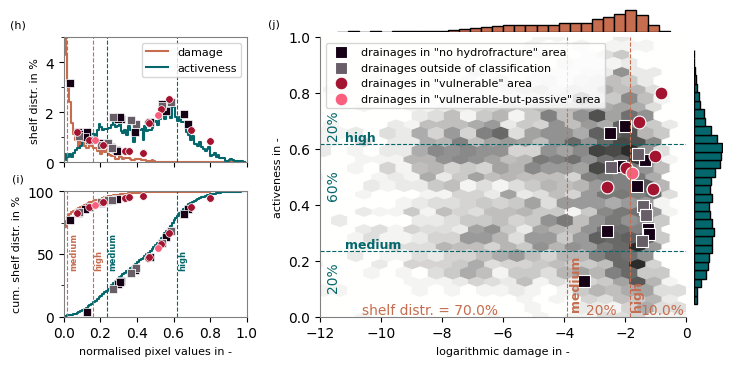

In [29]:
color_dmg = "#c66d50"
color_act = "#04676c"
number_bins = 100

fig, axes = plt.subplots(2, 2,
                         figsize=(total_width, 9 / 2.54),
                         width_ratios=[1, 2],
                         constrained_layout=True)

dmg_plot = dmgs[i_year_show].copy()
act_plot = acts[i_year_show].copy()
#act_plot[act_plot < 0.01] = np.nan

dmg_hist = np.histogram(dmg_plot[np.isfinite(dmg_plot)].flatten(), bins=number_bins)
act_hist = np.histogram(act_plot[np.isfinite(act_plot)].flatten(), bins=number_bins)

# Remove upper right subplot, replace with single hexbin
gs = axes[0, 1].get_gridspec()
for ax in axes[:2, 1]:
    ax.remove()

ax_hist = axes[0, 0]
ax_hist_cum = axes[1, 0]



ax_hex = fig.add_subplot(gs[:, 1])
ax_hex.hexbin(x=np.log(dmg_plot).flatten(),
              y=act_plot.flatten(),
              gridsize=28, cmap=cmap_gray)
ax_hex.spines['right'].set_visible(False)
ax_hex.spines['top'].set_visible(False)

ax_hex.set_xlim(-12, 0)
ax_hex.set_ylim(0, 1)
ax_hex.set_xlabel("logarithmic damage in -", fontsize=8)
ax_hex.set_ylabel("activeness in -", fontsize=8)
fig.text(
        1.15, 1.1, "(j)",
        transform=ax_hist.transAxes,
        fontsize=8,
        ha='center',
        va='center',
        color='black',
        zorder=21
    )
# Scatter points
ax_hex.scatter(np.log(events_lai_no["dmg"]), events_lai_no["act"], marker='s',
               facecolor=lai_no_color, edgecolors='white', lw=0.8, s=85, label ='drainages in "no hydrofracture" area')
ax_hex.scatter(np.log(events_lai_nan["dmg"]), events_lai_nan["act"], marker='s',
                facecolor=lai_nan_color, edgecolors='white', lw=0.8, s=85, label='drainages outside of classification')
ax_hex.scatter(np.log(events_lai_vul["dmg"]), events_lai_vul["act"], marker='o',
               facecolor=lai_vulnerable_color, edgecolors='white', lw=0.8, s=85, label='drainages in "vulnerable" area')
ax_hex.scatter(np.log(events_passive["dmg"]), events_passive["act"], marker='o',
               facecolor=fuerst_color, edgecolors='white', lw=0.8, s=85, label = 'drainages in "vulnerable-but-passive" area')
ax_hex.legend(loc='upper left', fontsize=8, frameon=True)


x_act_label = -11.8
x_act_label1 = -11.2
ax_hex.axhline(y=act_limit_medium, color=color_act, linestyle='--', lw=0.8, label='medium activeness limit')
ax_hex.axhline(y=act_limit_high, color=color_act, linestyle='--', lw=0.8, label='high activeness limit')
ax_hex.text(x_act_label1, act_limit_medium + 0.01, 'medium', color=color_act, fontsize=9, ha='left', fontweight='bold')
ax_hex.text(x_act_label1, act_limit_high + 0.01, 'high', color=color_act, fontsize=9, ha='left', fontweight='bold')
ax_hex.text(x_act_label, (act_limit_medium - 0) / 2.4 + 0, f"{act_fractions[0]*100:.0f}%", color=color_act, fontsize=10, ha='left', rotation=90)
ax_hex.text(x_act_label, (act_limit_high - act_limit_medium) / 2 + act_limit_medium, f"{act_fractions[1]*100:.0f}%", color=color_act, fontsize=10, ha='left', rotation=90)
ax_hex.text(x_act_label, (1 - act_limit_high) / 14 + act_limit_high, f"{act_fractions[2]*100:.0f}%", color=color_act, fontsize=10, ha='left', rotation=90)

y_dmg_label = 0.03
ax_hex.axvline(x=np.log(dmg_limit_medium), color=color_dmg, linestyle='--', lw=0.8, label='medium damage limit')
ax_hex.axvline(x=np.log(dmg_limit_high), color=color_dmg, linestyle='--', lw=0.8, label='high damage limit')
ax_hex.text(np.log(dmg_limit_medium) + 0.05, y_dmg_label, 'medium', color=color_dmg, fontsize=9, ha='left', rotation=90, fontweight='bold')
ax_hex.text(np.log(dmg_limit_high) + 0.05, y_dmg_label, 'high', color=color_dmg, fontsize=9, ha='left', rotation=90, fontweight='bold')
ax_hex.text((-12 - np.log(dmg_limit_medium))/ 1.8 + np.log(dmg_limit_medium), 0.01, f"shelf distr. = {dmg_fractions[0]*100:.1f}%", color=color_dmg, fontsize=10, ha='center')
ax_hex.text((np.log(dmg_limit_medium) - np.log(dmg_limit_high))/ 2.2 + np.log(dmg_limit_high), 0.01, f"{dmg_fractions[1]*100:.0f}%", color=color_dmg, fontsize=10, ha='center')
ax_hex.text((np.log(dmg_limit_high) - 0)/ 2.4 + 0, 0.01, f"{dmg_fractions[2]*100:.1f}%", color=color_dmg, fontsize=10, ha='center')

# Inset histogram (top)
ax_top = inset_axes(ax_hex,
                    width="100%",  # relative to parent
                    height="20%",
                    loc='upper center',
                    bbox_to_anchor=(0, 0.7, 1, 0.4),
                    bbox_transform=ax_hex.transAxes,
                    borderpad=0)
ax_top.hist(np.log(dmg_plot).flatten(), bins=30,
            facecolor=color_dmg, edgecolor='black')
ax_top.axis('off')

# Inset histogram (right)
ax_right = inset_axes(ax_hex,
                      width="20%",
                      height="100%",
                      loc='center right',
                      bbox_to_anchor=(0.7, 0, 0.4, 1),
                      bbox_transform=ax_hex.transAxes,
                      borderpad=0)
ax_right.hist(act_plot.flatten(), bins=30, orientation='horizontal',
              facecolor=color_act, edgecolor='black')
ax_right.axis('off')

# Histgram
dmg_counts = dmg_hist[0] / dmg_hist[0].sum()
dmg_bins = dmg_hist[1][:-1]
act_counts = act_hist[0] / act_hist[0].sum()
act_bins = act_hist[1][:-1]
events_act = events["act"].values
events_dmg = events["dmg"].values
ms = 30

ax_hist.step(dmg_bins, dmg_counts * 100, color=color_dmg, lw=1.5, label='damage')
ax_hist.step(act_bins, act_counts * 100, color=color_act, lw=1.5, label='activeness')
for (df, color, m) in zip(
    [events_lai_no, events_lai_nan, events_lai_vul, events_passive],
    [lai_no_color, lai_nan_color, lai_vulnerable_color, fuerst_color],
    ["s", "s", "o", "o"]):
    ax_hist.scatter(df["act"], np.interp(df["act"], act_bins, act_counts * 100) + 0.3, marker=m, s=ms, color=color, edgecolors='white', lw=0.5, zorder = 10, clip_on=False)
    ax_hist.scatter(df["dmg"], np.interp(df["dmg"], dmg_bins, dmg_counts * 100) + 0.3, marker=m, s=ms, color=color, edgecolors='white', lw=0.5, zorder = 10, clip_on=False)

ax_hist.axvline(x=dmg_limit_medium, color=color_dmg, linestyle='--', lw=0.8)
ax_hist.axvline(x=dmg_limit_high, color=color_dmg, linestyle='--', lw=0.8)
ax_hist.axvline(x=act_limit_medium, color=color_act, linestyle='--', lw=0.8)
ax_hist.axvline(x=act_limit_high, color=color_act, linestyle='--', lw=0.8)
ax_hist.set_xlim(0, 1)
ax_hist.set_ylim(0, 5)
ax_hist.set_ylabel("shelf distr. in %", fontsize=8)
ax_hist.tick_params(labelbottom=False)
ax_hist.xaxis.set_major_locator(MultipleLocator(0.2))
ax_hist.yaxis.set_major_locator(MultipleLocator(2))
ax_hist.yaxis.set_minor_locator(AutoMinorLocator(2))
ax_hist.legend(loc = 'upper right', fontsize=8, frameon=True)
fig.text(
        -0.25, 1.1, "(h)",
        transform=ax_hist.transAxes,
        fontsize=8,
        ha='center',
        va='center',
        color='black',
        zorder=21
    )

# Histgram
ax_hist_cum.step(dmg_bins, np.cumsum(dmg_counts) * 100, color=color_dmg, lw=1.5, label='damage')
ax_hist_cum.step(act_bins, np.cumsum(act_counts) * 100, color=color_act, lw=1.5, label='activeness')
for (df, color, m) in zip(
    [events_lai_no, events_lai_nan, events_lai_vul, events_passive],
    [lai_no_color, lai_nan_color, lai_vulnerable_color, fuerst_color],
    ["s", "s", "o", "o"]):
    ax_hist_cum.scatter(df["act"], np.interp(df["act"], act_bins, np.cumsum(act_counts) * 100 ) - 3, marker=m, s=ms, color=color, edgecolors='white', lw=0.5, zorder = 10, clip_on=False)
    ax_hist_cum.scatter(df["dmg"], np.interp(df["dmg"], dmg_bins, np.cumsum(dmg_counts) * 100 ) - 3, marker=m, s=ms, color=color, edgecolors='white', lw=0.5, zorder = 10, clip_on=False)
ax_hist_cum.axvline(x=dmg_limit_medium, color=color_dmg, linestyle='--', lw=0.8)
ax_hist_cum.axvline(x=dmg_limit_high, color=color_dmg, linestyle='--', lw=0.8)
ax_hist_cum.axvline(x=act_limit_medium, color=color_act, linestyle='--', lw=0.8)
ax_hist_cum.axvline(x=act_limit_high, color=color_act, linestyle='--', lw=0.8)
ax_hist_cum.text(x = act_limit_medium + 0.01, y = 37, s = "medium", color=color_act, fontsize=6, ha='left', va = "bottom", rotation=90, fontweight='bold')
ax_hist_cum.text(x = act_limit_high + 0.01, y = 37, s = "high", color=color_act, fontsize=6, ha='left', va = "bottom", rotation=90, fontweight='bold')
ax_hist_cum.text(x = dmg_limit_medium + 0.01, y = 37, s = "medium", color=color_dmg, fontsize=6, ha='left', va = "bottom", rotation=90, fontweight='bold')
ax_hist_cum.text(x = dmg_limit_high + 0.01, y = 37, s = "high", color=color_dmg, fontsize=6, ha='left', va = "bottom", rotation=90, fontweight='bold')
ax_hist_cum.set_xlim(0, 1)
ax_hist_cum.set_ylim(0, 100)
ax_hist_cum.set_ylabel("cum. shelf distr. in %", fontsize=8)
ax_hist_cum.set_xlabel("normalised pixel values in -", fontsize=8)
ax_hist_cum.xaxis.set_major_locator(MultipleLocator(0.2))
ax_hist_cum.yaxis.set_major_locator(MultipleLocator(50))
ax_hist_cum.yaxis.set_minor_locator(AutoMinorLocator(2))
fig.text(
        -0.25, 1.1, "(i)",
        transform=ax_hist_cum.transAxes,
        fontsize=8,
        ha='center',
        va='center',
        color='black',
        zorder=21
    )

# Settings
for ax in [ax_hist, ax_hist_cum, ax_hex]:
    ax.spines["bottom"].set_color("gray")
    ax.spines["top"].set_color("gray")
    ax.spines["left"].set_color("gray")
    ax.spines["right"].set_color("gray")

# Save
plt.tight_layout()
fig.savefig(os.path.join(figure_folder, "figure_02c.png"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(figure_folder, "figure_02c.pdf"), dpi=300, bbox_inches='tight')
plt.show()